In [139]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import re
from scipy.stats import percentileofscore

In [162]:
#print all csv files from the allocation_by_district folder
#note: not in order!
seeds_by_district_csv_files=glob.glob('./allocation_by_district/*.csv')
# seeds_by_district_csv_files

#alt method for printing all the files...
# for files in glob.glob("./allocation_by_district/*.csv"):
#     print(files) 

#this will get an unsorted list of seeds for all files in ./allocation_by_district folder
district_seeds_list=[]
for fname in seeds_by_district_csv_files:
    res = re.findall("seed_(\d+)_by_district.csv", fname)
    if not res: continue
    district_seeds_list.append(res[0]) # You can append the result to a list

In [163]:
district_seeds_list_sorted=sorted(district_seeds_list)

In [164]:
# path is a string for the path of the folder we want to check
# path = os.getcwd() + '/allocation_by_county'
path = os.getcwd() + '/allocation_by_district'

#list of all filenames in the path which end in .csv
csv_files = glob.glob(os.path.join(path, "*.csv")) 
num_files = len(csv_files) #count of all files

# file_name = './allocation_by_county/seed_{}_by_county.csv'
file_name = './allocation_by_district/seed_{}_by_district.csv'
df_list = []

# This previously worked when all seeds were saved regardless of criteria being met
# for i in range(num_files):
#    iter_number=str(i).rjust(3,'0')
#    df_list.append(pd.read_csv(file_name.format(iter_number)))

for seed in district_seeds_list_sorted:
    df_list.append(pd.read_csv(file_name.format(seed)))


In [137]:
df=pd.read_csv('./allocation_by_district/seed_005_by_district.csv')
df.head()

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((586099.1957320713 4634978.60759052, ...",797813,595545.572592,4.720060e+06,1,3.271485e+10,9.741866e+05,0.433182,150421.382871,0.460231
1,"POLYGON ((290045.8112146391 4559549.899938692,...",795792,345247.851796,4.714904e+06,2,5.583284e+10,1.305045e+06,0.411954,179144.205126,0.553776
2,POLYGON ((413996.78923838487 4491953.713269984...,797831,387573.365831,4.553582e+06,3,2.541417e+10,7.651602e+05,0.545483,126950.783530,0.501944
3,POLYGON ((491768.13570150826 4518326.457960803...,798933,575272.437018,4.578805e+06,4,3.173624e+10,9.641297e+05,0.429037,137608.168357,0.533479


In [165]:
full_nestedlist=[]
for j in range(num_files):
    temp_df = df_list[j]
    list_for_j=[j, temp_df.loc[0,'Reock'],temp_df.loc[1,'Reock'],temp_df.loc[2,'Reock'],temp_df.loc[3,'Reock'],
                temp_df['Reock'].min(),temp_df['Reock'].max(),temp_df['Reock'].mean(),
    temp_df.loc[0,'PolsbyPopper'],temp_df.loc[1,'PolsbyPopper'],
    temp_df.loc[2,'PolsbyPopper'],temp_df.loc[3,'PolsbyPopper'],
                temp_df['PolsbyPopper'].min(),temp_df['PolsbyPopper'].max(),temp_df['PolsbyPopper'].mean(),
    temp_df['population'].min(),temp_df['population'].max()
    ]
    full_nestedlist.append(list_for_j)

# full_nestedlist


In [166]:
column_dict=[
    'seed',
    'Reock_d1',
    'Reock_d2',
    'Reock_d3',
    'Reock_d4',
    'Reock_min',
    'Reock_max',
    'Reock_mean',
    'PP_d1',
    'PP_d2',
    'PP_d3',
    'PP_d4',
    'PP_min',
    'PP_max',
    'PP_mean',
    'min_pop',
    'max_pop']

In [167]:
compactness_data_df = pd.DataFrame(full_nestedlist,columns=column_dict)

In [168]:
column_dict_analysis=[
    'seed',
    'Reock_min',
    'Reock_max',
    'Reock_mean',
    'PP_min',
    'PP_max',
    'PP_mean',
    'min_pop',
    'max_pop']

In [169]:
compactness_analysis_df = compactness_data_df[column_dict_analysis]
compactness_analysis_df

,seed,Reock_min,Reock_max,Reock_mean,PP_min,PP_max,PP_mean,min_pop,max_pop
0,0,0.332951,0.427819,0.367877,0.235157,0.355242,0.302992,790938,804784
1,1,0.448682,0.567162,0.508731,0.338438,0.498848,0.435282,791513,802747
2,2,0.428981,0.562479,0.490348,0.294441,0.384121,0.339815,791071,804852
3,3,0.342567,0.431556,0.388122,0.288226,0.409789,0.358882,795671,800138
4,4,0.460231,0.553776,0.512357,0.411954,0.545483,0.454914,795792,798933
...,...,...,...,...,...,...,...,...,...
145,145,0.398102,0.661963,0.509946,0.407988,0.513990,0.455868,793346,802154
146,146,0.300590,0.532673,0.429413,0.186259,0.509582,0.324151,793681,801769
147,147,0.302125,0.453127,0.398841,0.348125,0.429952,0.386566,791046,804077
148,148,0.186280,0.339700,0.279657,0.144578,0.322961,0.230056,790611,803955


In [161]:
compactness_analysis_df.to_csv('./data/compactness_scores_simulations.csv', index=False, header=True)

In [11]:
#show all rows instead of first 5/last 5
# pd.set_option('display.max_rows', None)
# compactness_analysis_df

#reset max_rows:
# pd.reset_option(“max_rows”)

In [12]:
enacted_map=pd.read_csv('enacted_map.csv')
enacted_map

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((597046.3063824802 4495965.241673183,...",797584,655223.617473,4.626175e+06,1,2.847289e+10,1.120709e+06,0.284876,160047.768111,0.353820
1,"POLYGON ((558251.4820985557 4634182.10198691, ...",797589,631594.469070,4.793646e+06,2,3.361224e+10,1.004718e+06,0.418426,141576.968905,0.533780
2,POLYGON ((413996.78923838487 4491953.713269984...,797551,376909.476792,4.576509e+06,3,2.782373e+10,9.971415e+05,0.351651,144824.951242,0.422259
3,"POLYGON ((299084.9524567265 4528678.815421122,...",797645,341387.505752,4.616499e+06,4,5.578923e+10,1.595846e+06,0.275282,191597.504183,0.483750


In [13]:
alternate_map=pd.read_csv('alt_map.csv')
alternate_map

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((659405.8034389731 4506627.439222173,...",797655,655223.617473,4.626175e+06,1,1.669426e+10,8.095316e+05,0.320118,116372.651805,0.392388
1,"POLYGON ((568721.6887085006 4527942.280230374,...",797556,631594.469070,4.793646e+06,2,4.045878e+10,1.265121e+06,0.317657,155907.333430,0.529822
2,POLYGON ((452694.19555372297 4492297.318383798...,797584,357154.753953,4.543364e+06,3,2.260122e+10,8.294785e+05,0.412792,136323.573265,0.387115
3,"POLYGON ((299084.9524567265 4528678.815421122,...",797574,376909.476792,4.576509e+06,4,6.594382e+10,1.557147e+06,0.341763,226406.411288,0.409493


In [ ]:
map_dict = { 'measure': ['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean']
            , 'enacted': [enacted_map['Reock'].min(),enacted_map['Reock'].mean(),enacted_map['PolsbyPopper'].min(),enacted_map['PolsbyPopper'].mean()]
            , 'alternate': [alternate_map['Reock'].min(),alternate_map['Reock'].mean(), alternate_map['PolsbyPopper'].min(),alternate_map['PolsbyPopper'].mean() ]}

In [15]:
maps_df=pd.DataFrame(map_dict)
maps_df

,measure,enacted,alternate
0,Reock_min,0.353820,0.387115
1,Reock_mean,0.448402,0.429705
2,PP_min,0.275282,0.317657
3,PP_mean,0.332559,0.348082


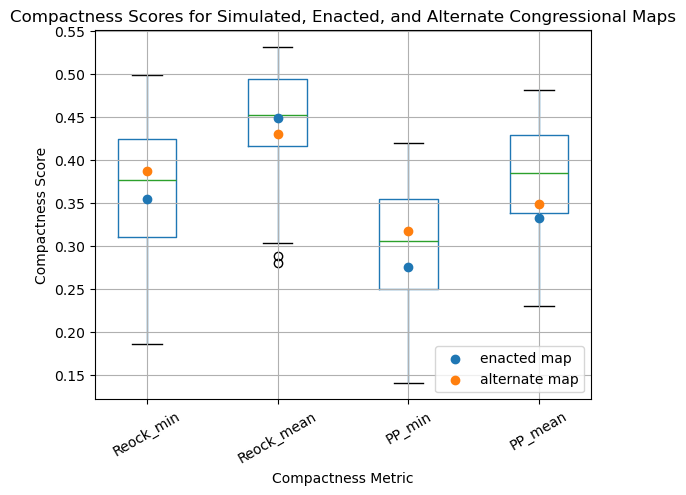

In [170]:
x = maps_df['measure']
y = maps_df['enacted']
b = maps_df['alternate']

compactness_analysis_df.boxplot(column=['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean'], rot=30, zorder=1, positions=range(4))
plt.scatter(x=x, y=y, label='enacted map', zorder=2)
plt.scatter(x=x, y=b, label='alternate map', zorder=3)
plt.xlabel('Compactness Metric')
plt.ylabel('Compactness Score')
plt.title('Compactness Scores for Simulated, Enacted, and Alternate Congressional Maps')
plt.legend(loc='lower right')
# maps_df.plot.scatter(x='measure', y='enacted', zorder=2)
plt.show()
# maps_df.plot.scatter(column=['Reock_min', 'Reock_mean', 'PP_mean', 'PP_min'], zorder=2)

#Need to edit the off set

Regarding above boxplots, the enacted map is at or below the median for all metrics. The least compact alternate map district is more optimally compact than the least compact enacted district. Additionallly, the least compact alternate district is above the median for both metrics. 

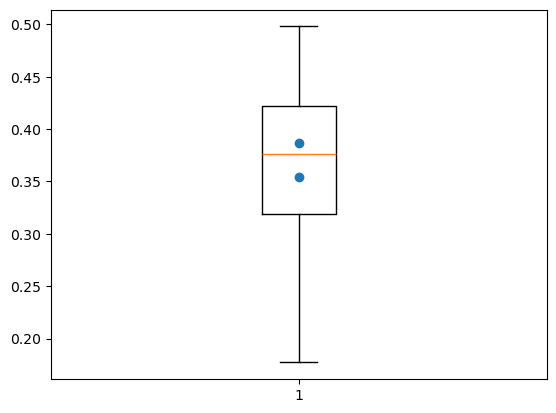

In [17]:
reock_min=maps_df.loc[maps_df['measure']=='Reock_min'][['enacted', 'alternate']]
plt.boxplot(x=compactness_analysis_df['Reock_min'], zorder=1)
plt.scatter(x=[1,1], y=reock_min, zorder=2)
plt.show()


## Computing percentiles of enacted and alternate maps

In [171]:
reock_min_array=compactness_analysis_df['Reock_min'].to_numpy()
reock_mean_array=compactness_analysis_df['Reock_mean'].to_numpy()
pp_min_array=compactness_analysis_df['PP_min'].to_numpy()
pp_mean_array=compactness_analysis_df['PP_mean'].to_numpy()

In [37]:
maps_df

,measure,enacted,alternate
0,Reock_min,0.353820,0.387115
1,Reock_mean,0.448402,0.429705
2,PP_min,0.275282,0.317657
3,PP_mean,0.332559,0.348082


In [172]:
#reock min percentile for enacted
print('Reock min percentile for enacted is', percentileofscore(reock_min_array, maps_df.iloc[0]['enacted']))

#reock min percentile for alternate
print('Reock min percentile for alternate is ', percentileofscore(reock_min_array, maps_df.iloc[0]['alternate']))

print('Reock mean percentile for enacted is',percentileofscore(reock_mean_array, maps_df.iloc[1]['enacted']) )

print('Reock mean percentile for alternate is',percentileofscore(reock_mean_array, maps_df.iloc[1]['alternate']) )

print('Polsby-Popper min percentile for enacted is', percentileofscore(pp_min_array, maps_df.iloc[2]['enacted']))

#reock min percentile for alternate
print('Polsby-Popper min percentile for alternate is ', percentileofscore(pp_min_array, maps_df.iloc[2]['alternate']))

print('Polsby-Popper mean percentile for enacted is', percentileofscore(pp_mean_array, maps_df.iloc[3]['enacted']))

#reock min percentile for alternate
print('Polsby-Popper mean percentile for alternate is ', percentileofscore(pp_mean_array, maps_df.iloc[3]['alternate']))

Reock min percentile for enacted is 41.33333333333333
Reock min percentile for alternate is  58.0
Reock mean percentile for enacted is 48.0
Reock mean percentile for alternate is 35.33333333333333
Polsby-Popper min percentile for enacted is 30.0
Polsby-Popper min percentile for alternate is  54.666666666666664
Polsby-Popper mean percentile for enacted is 21.333333333333332
Polsby-Popper mean percentile for alternate is  30.0


## Calculating population deviation

In [52]:
ideal_population=797592.25

In [76]:
(((enacted_map['population']-ideal_population).abs())/ideal_population)*100

0    0.001034
1    0.000407
2    0.005172
3    0.006614
Name: population, dtype: float64

In [77]:
(((alternate_map['population']-ideal_population).abs())/ideal_population)*100

0    0.007867
1    0.004545
2    0.001034
3    0.002288
Name: population, dtype: float64

In [80]:
print('mean population deviation for enacted map is', ((((enacted_map['population']-ideal_population).abs())/ideal_population).mean())*100)
print('mean population deviation for the alternate map is', ((((alternate_map['population']-ideal_population).abs())/ideal_population).mean())*100)

mean population deviation for enacted map is 0.003306827517443907
mean population deviation for the alternate map is 0.003933714250608628


## Removing simulated maps that don't fall in 1% deviation (relevant for 7/31/25 to prep Iowa_districtgenerator to rerun seeds)

In [81]:
min_district=ideal_population*.99
max_district=ideal_population*1.01
print(min_district, max_district)

789616.3275 805568.1725


In [90]:
maps_within_pop_range=compactness_data_df.loc[(compactness_data_df['min_pop']>min_district) & (compactness_data_df['max_pop']<max_district)]['seed'].tolist()

In [115]:
maps_within_pop_range
maps_within_pop_range_list=[]
for number in maps_within_pop_range:
    maps_within_pop_range_list.append(str(number).rjust(3, '0'))

In [124]:
seeds=list(range(260))
seeds_list = []
for seed_number in seeds:
    seeds_list.append(str(seed_number).rjust(3, '0'))

In [ ]:
seeds_to_rerun = [seed for seed in seeds_list if seed not in maps_within_pop_range_list]
# =seeds_list.remove(maps_within_pop_range_list)
len(seeds_to_rerun)

170

In [ ]:
file_name = './allocation_by_district/seed_{}_by_district.csv'

for iter_number in seeds_to_rerun:
#    iter_number=str(i).rjust(3,'0')
    os.remove(file_name.format(iter_number))
#    df_list.append(pd.read_csv(file_name.format(iter_number)))

In [129]:
file_name_county = './allocation_by_county/seed_{}_by_county.csv'
for iter_number in seeds_to_rerun:
    os.remove(file_name_county.format(iter_number))


In [133]:
file_name_distmap = './district_maps/seed_{}_district_map.png'
for iter_number in seeds_to_rerun:
    os.remove(file_name_distmap.format(iter_number))

In [132]:
seeds_to_rerun_ints = [seed for seed in seeds if seed not in maps_within_pop_range]
# seeds_to_rerun_ints